In [1]:
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.18.0


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')
# TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense, 
                                      Dropout, Multiply, Softmax, Lambda)
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K
df     = pd.read_csv('waca_dataset.csv')
TARGET = df['target_channel'].iloc[0]

feature_cols = [c for c in df.columns
                if c.endswith(('_mean','_std','_max','_min'))
                and TARGET not in c]

X = df[feature_cols].values
y = df['target_busy'].values
print(f"Features: {len(feature_cols)}")
print(f"Busy: {y.sum()}, Idle: {len(y)-y.sum()}")

Features: 92
Busy: 60, Idle: 140


In [3]:
# Scale features
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)
# LSTM needs 3D input: (samples, timesteps, features)
# treating each group of 4 features (mean,std,max,min) as 1 timestep
# 92 features / 4 = 23 timesteps
n_features_per_step = 4
n_timesteps = len(feature_cols) // n_features_per_step
X_lstm = X_scaled[:, :n_timesteps*n_features_per_step]
X_lstm = X_lstm.reshape(len(X_lstm), n_timesteps, n_features_per_step)
print(f"LSTM input shape: {X_lstm.shape}")
print(f"  → {X_lstm.shape[0]} samples")
print(f"  → {X_lstm.shape[1]} timesteps (channels)")  
print(f"  → {X_lstm.shape[2]} features per timestep")
X_train, X_test, y_train, y_test = train_test_split(
    X_lstm, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTrain: {len(X_train)}, Test: {len(X_test)}")

LSTM input shape: (200, 23, 4)
  → 200 samples
  → 23 timesteps (channels)
  → 4 features per timestep

Train: 160, Test: 40


In [4]:
def build_lstm_attention_single(n_timesteps, n_features):
    inputs = Input(shape=(n_timesteps, n_features), name='input')
    
    # LSTM layer
    lstm_out = LSTM(64, return_sequences=True, name='lstm')(inputs)
    lstm_out = Dropout(0.3, name='dropout_1')(lstm_out)  
    
    # Attention mechanism
    attention = Dense(1, activation='tanh', name='attention_score')(lstm_out)
    attention_weights = Softmax(axis=1, name='attention_weights')(attention)
    
    # weighted sum
    context = Multiply(name='context')([lstm_out, attention_weights])
    context = Lambda(lambda x: K.sum(x, axis=1), name='weighted_sum')(context)
    
    # Output layers
    dense = Dense(32, activation='relu', name='dense')(context)
    dense = Dropout(0.2, name='dropout_2')(dense)          # unique name
    output = Dense(1, activation='sigmoid', name='output')(dense)
    
    # Model with a single output (classification only)
    model = Model(inputs=inputs, outputs=output)
    
    # Storing the attention layer so we can extract it later
    model.attention_layer = attention_weights
    return model

# Build the model
model = build_lstm_attention_single(n_timesteps, n_features_per_step)

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)            │ (None, 23, 4)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, 23, 64)            │          17,664 │ input[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 23, 64)            │               0 │ lstm[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_score (Dense)       │ (None, 23, 1)             │              65 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_weights (Softmax)   │ (None, 23, 1)             │               0 │ attention_score[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ context (Multiply)            │ (None, 23, 64)            │               0 │ dropout_1[0][0],           │
│                               │                           │                 │ attention_weights[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ weighted_sum (Lambda)         │ (None, 64)                │               0 │ context[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 32)                │           2,080 │ weighted_sum[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 32)                │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output (Dense)                │ (None, 1)                 │              33 │ dropout_2[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 19,842 (77.51 KB)

 Trainable params: 19,842 (77.51 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
#Train LSTM
early_stop = EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 151ms/step - accuracy: 0.6328 - loss: 0.6791 - val_accuracy: 0.5938 - val_loss: 0.6782
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7109 - loss: 0.6508 - val_accuracy: 0.5312 - val_loss: 0.6668
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7344 - loss: 0.6170 - val_accuracy: 0.5625 - val_loss: 0.6592
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7422 - loss: 0.5639 - val_accuracy: 0.5625 - val_loss: 0.7109
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7344 - loss: 0.5374 - val_accuracy: 0.5625 - val_loss: 0.7660
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7344 - loss: 0.5399 - val_accuracy: 0.5625 - val_loss: 0.7503
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7422 - loss: 0.5080 - val_accuracy: 0.5938 - val_loss: 0.6889
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7344 - loss: 0.4754 - val_accuracy: 0.6250 - val_loss: 0.7080

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 456ms/step
LSTM CLASSIFICATION
Accuracy: 67.50%
F1 Score: 0.6286
              precision    recall  f1-score   support

        Idle       0.94      0.57      0.71        28
        Busy       0.48      0.92      0.63        12

    accuracy                           0.68        40
   macro avg       0.71      0.74      0.67        40
weighted avg       0.80      0.68      0.69        40



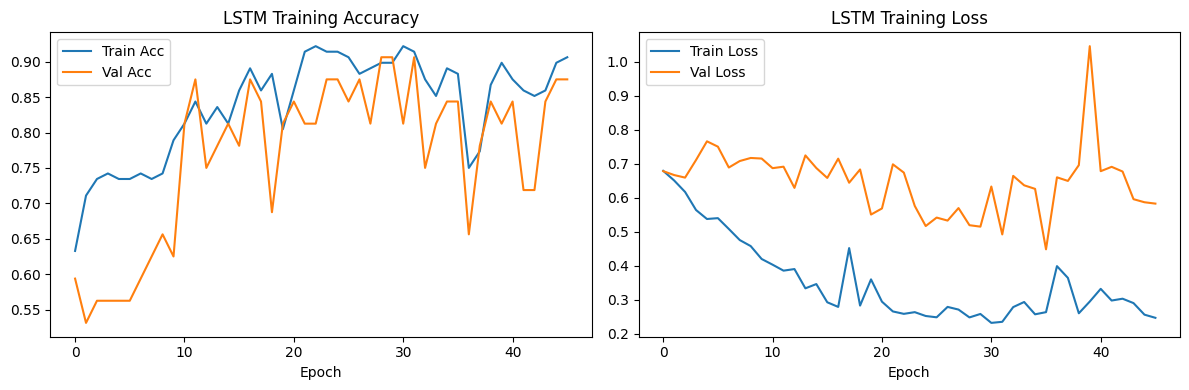

In [6]:
#Evaluate LSTM (single‑output model)
y_pred_prob = model.predict(X_test) 
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
attention_model = Model(inputs=model.input, outputs=model.attention_layer)
attention_weights = attention_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)

print("LSTM CLASSIFICATION")
print(f"Accuracy: {acc*100:.2f}%")
print(f"F1 Score: {f1:.4f}")
print(classification_report(y_test, y_pred, target_names=['Idle','Busy']))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('LSTM Training Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('LSTM Training Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training.png', bbox_inches='tight')
plt.show()

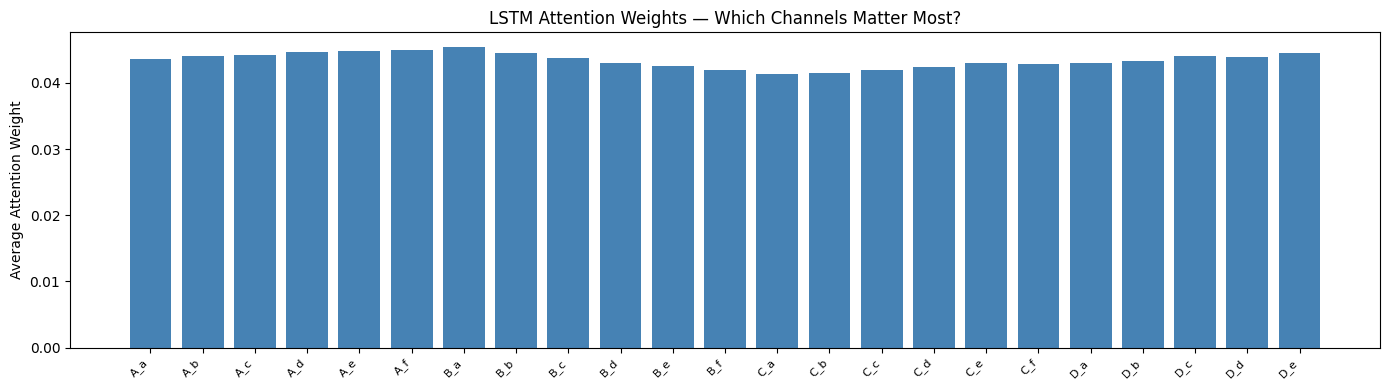

In [7]:
#Attention Heatmap (XAI for LSTM)
avg_attention = attention_weights.mean(axis=0).flatten()
# Channel group labels (A_a, A_b ... D_f)
groups = [f'{g}_{s}' for g in ['A','B','C','D'] 
          for s in ['a','b','c','d','e','f']]
# Use first n_timesteps
timestep_labels = groups[:n_timesteps]

plt.figure(figsize=(14, 4))
plt.bar(range(len(avg_attention)), avg_attention, color='steelblue')
plt.xticks(range(len(avg_attention)), 
           timestep_labels, rotation=45, ha='right', fontsize=8)
plt.title('LSTM Attention Weights — Which Channels Matter Most?')
plt.ylabel('Average Attention Weight')
plt.tight_layout()
plt.savefig('lstm_attention_heatmap.png', bbox_inches='tight')
plt.show()

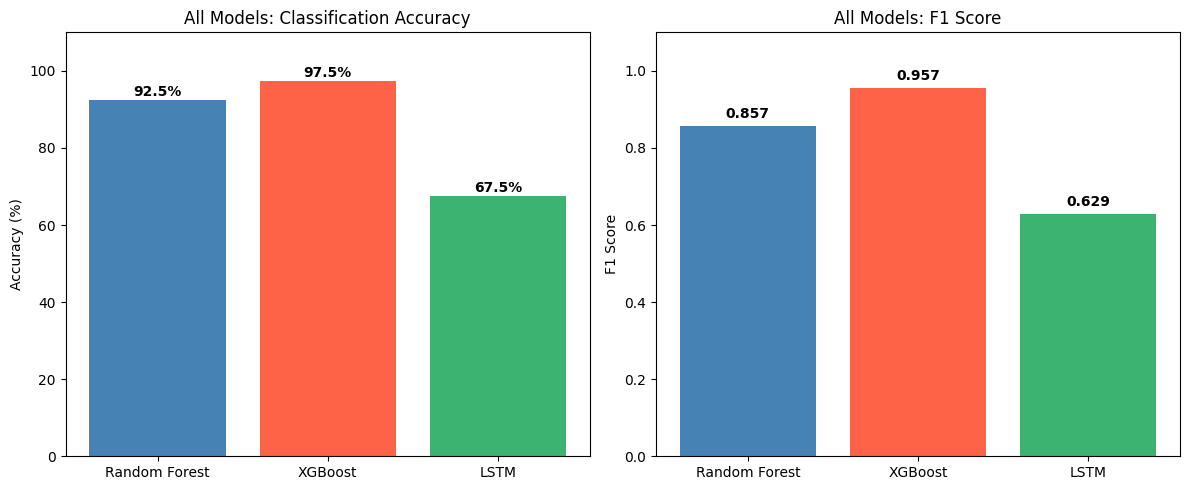


FINAL SUMMARY
Random Forest  : Accuracy=92.5%  F1=0.8571
XGBoost        : Accuracy=97.5%  F1=0.9565
LSTM           : Accuracy=67.5%  F1=0.6286


In [8]:
# Final Model Comparison (all 3 models)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Reload RF and XGB results
X_flat = X_scaled
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42, stratify=y)

rf  = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(n_estimators=100, random_state=42,
                     eval_metric='logloss', verbosity=0)
rf.fit(Xf_train, yf_train)
xgb.fit(Xf_train, yf_train)

acc_rf  = accuracy_score(yf_test, rf.predict(Xf_test))
acc_xgb = accuracy_score(yf_test, xgb.predict(Xf_test))
f1_rf   = f1_score(yf_test, rf.predict(Xf_test))
f1_xgb  = f1_score(yf_test, xgb.predict(Xf_test))

models      = ['Random Forest', 'XGBoost', 'LSTM']
accuracies  = [acc_rf*100, acc_xgb*100, acc*100]
f1_scores   = [f1_rf, f1_xgb, f1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(models, accuracies, color=['steelblue','tomato','mediumseagreen'])
axes[0].set_title('All Models: Classification Accuracy')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 110)
for i, v in enumerate(accuracies):
    axes[0].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(models, f1_scores, color=['steelblue','tomato','mediumseagreen'])
axes[1].set_title('All Models: F1 Score')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(f1_scores):
    axes[1].text(i, v+0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('all_models_comparison.png', bbox_inches='tight')
plt.show()
print("\nFINAL SUMMARY")
for m, a, f in zip(models, accuracies, f1_scores):
    print(f"{m:15s}: Accuracy={a:.1f}%  F1={f:.4f}")